# Synthetic Control Method

# Data

In [1]:
import pandas as pd
from causalis.scenarios.synthetic_control.dgp import generate_scm_gamma_26

df = generate_scm_gamma_26(
    return_panel_data=False,
    include_oracles=True,
)

# Treated post-period rows are exactly treated_time == 1
post_treated = df[df["treated_time"] == 1].copy()
atte_true = post_treated["tau_realized_true"].mean()
print(f"Ground-truth ATTE is {atte_true:.6f}")


Ground-truth ATTE is 1.919269


In [2]:
df.head()

,unit_id,calendar_time,treated_time,y,y_cf,tau_realized_true,mu_cf,mu_treated,tau_mean_true
0,donor_1,2000-01,0,9.971611,9.971611,0.0,10.059081,10.059081,0.0
1,donor_1,2000-02,0,10.344379,10.344379,0.0,10.097467,10.097467,0.0
2,donor_1,2000-03,0,10.998498,10.998498,0.0,11.354098,11.354098,0.0
3,donor_1,2000-04,0,11.508717,11.508717,0.0,11.277716,11.277716,0.0
4,donor_1,2000-05,0,11.125281,11.125281,0.0,10.098791,10.098791,0.0


In [3]:
from causalis.data_contracts import PanelDataSCM

paneldata = PanelDataSCM(
    df=df,
    y='y',
    unit_col='unit_id',
    time_col='calendar_time',
    treated_time='treated_time'
)

# EDA

In [4]:
paneldata

PanelDataSCM(df=(1763, 4), y='y', unit_col='unit_id', time_col='calendar_time', treated_time='treated_time', time_freq='M', treated_unit='treated', treatment_start=Period('2003-02', 'M'), last_post_period=Period('2003-07', 'M'), n_pre_periods=37, n_post_periods=6, donor_units=['donor_1', 'donor_10', 'donor_11', 'donor_12', 'donor_13', 'donor_14', 'donor_15', 'donor_16', 'donor_17', 'donor_18', 'donor_19', 'donor_2', 'donor_20', 'donor_21', 'donor_22', 'donor_23', 'donor_24', 'donor_25', 'donor_26', 'donor_27', 'donor_28', 'donor_29', 'donor_3', 'donor_30', 'donor_31', 'donor_32', 'donor_33', 'donor_34', 'donor_35', 'donor_36', 'donor_37', 'donor_38', 'donor_39', 'donor_4', 'donor_40', 'donor_5', 'donor_6', 'donor_7', 'donor_8', 'donor_9'])

In [5]:
from causalis.scenarios.synthetic_control.refutation import donors_diagnostics
donors_diagnostics(paneldata)

,donor,pre_mean,pre_std,pre_slope,corr_with_treated_pre,rmse_to_treated_pre,rmse_to_treated_pre_standardized,mean_diff_pre,slope_diff_pre,max_abs_gap_pre,is_never_treated,n_missing_pre,corr_rank,std_rmse_rank,slope_rank,composite_similarity_score,rank_by_similarity,notes
0,donor_20,20.756877,4.235256,0.065672,0.699298,3.050574,1.177242,0.055800,0.001045,7.515230,True,0,6,2,1,0.950000,1,high_std_rmse
1,donor_23,18.859982,3.459160,0.109325,0.792879,2.802849,1.081642,-1.841096,0.044698,6.193337,True,0,1,1,19,0.850000,2,high_std_rmse
2,donor_17,27.374399,5.004251,0.062159,0.694945,7.633294,2.945751,6.673322,-0.002467,15.022205,True,0,7,23,3,0.750000,3,high_std_rmse
3,donor_35,12.890196,2.478484,0.054896,0.774341,7.995072,3.085364,-7.810882,-0.009730,11.244939,True,0,2,25,7,0.741667,4,high_std_rmse
4,donor_27,12.138052,2.561773,0.065732,0.710107,8.784934,3.390178,-8.563025,0.001106,12.226100,True,0,4,29,2,0.733333,5,high_std_rmse
5,donor_39,15.933235,3.493479,0.101601,0.756099,5.287926,2.040654,-4.767843,0.036974,9.398086,True,0,3,16,16,0.733333,6,high_std_rmse
6,donor_2,22.023910,3.752940,0.025593,0.599773,3.299044,1.273128,1.322833,-0.039033,8.913091,True,0,19,4,17,0.691667,7,high_std_rmse
7,donor_34,23.225266,4.258988,0.116799,0.685302,4.012347,1.548398,2.524189,0.052173,8.782578,True,0,8,11,21,0.691667,8,high_std_rmse
8,donor_26,15.531548,2.367240,0.058569,0.584382,5.645636,2.178697,-5.169529,-0.006057,10.132082,True,0,21,18,5,0.658333,9,high_std_rmse
9,donor_9,20.198346,3.894696,0.185173,0.609819,3.134843,1.209762,-0.502731,0.120546,10.776096,True,0,15,3,31,0.616667,10,high_std_rmse


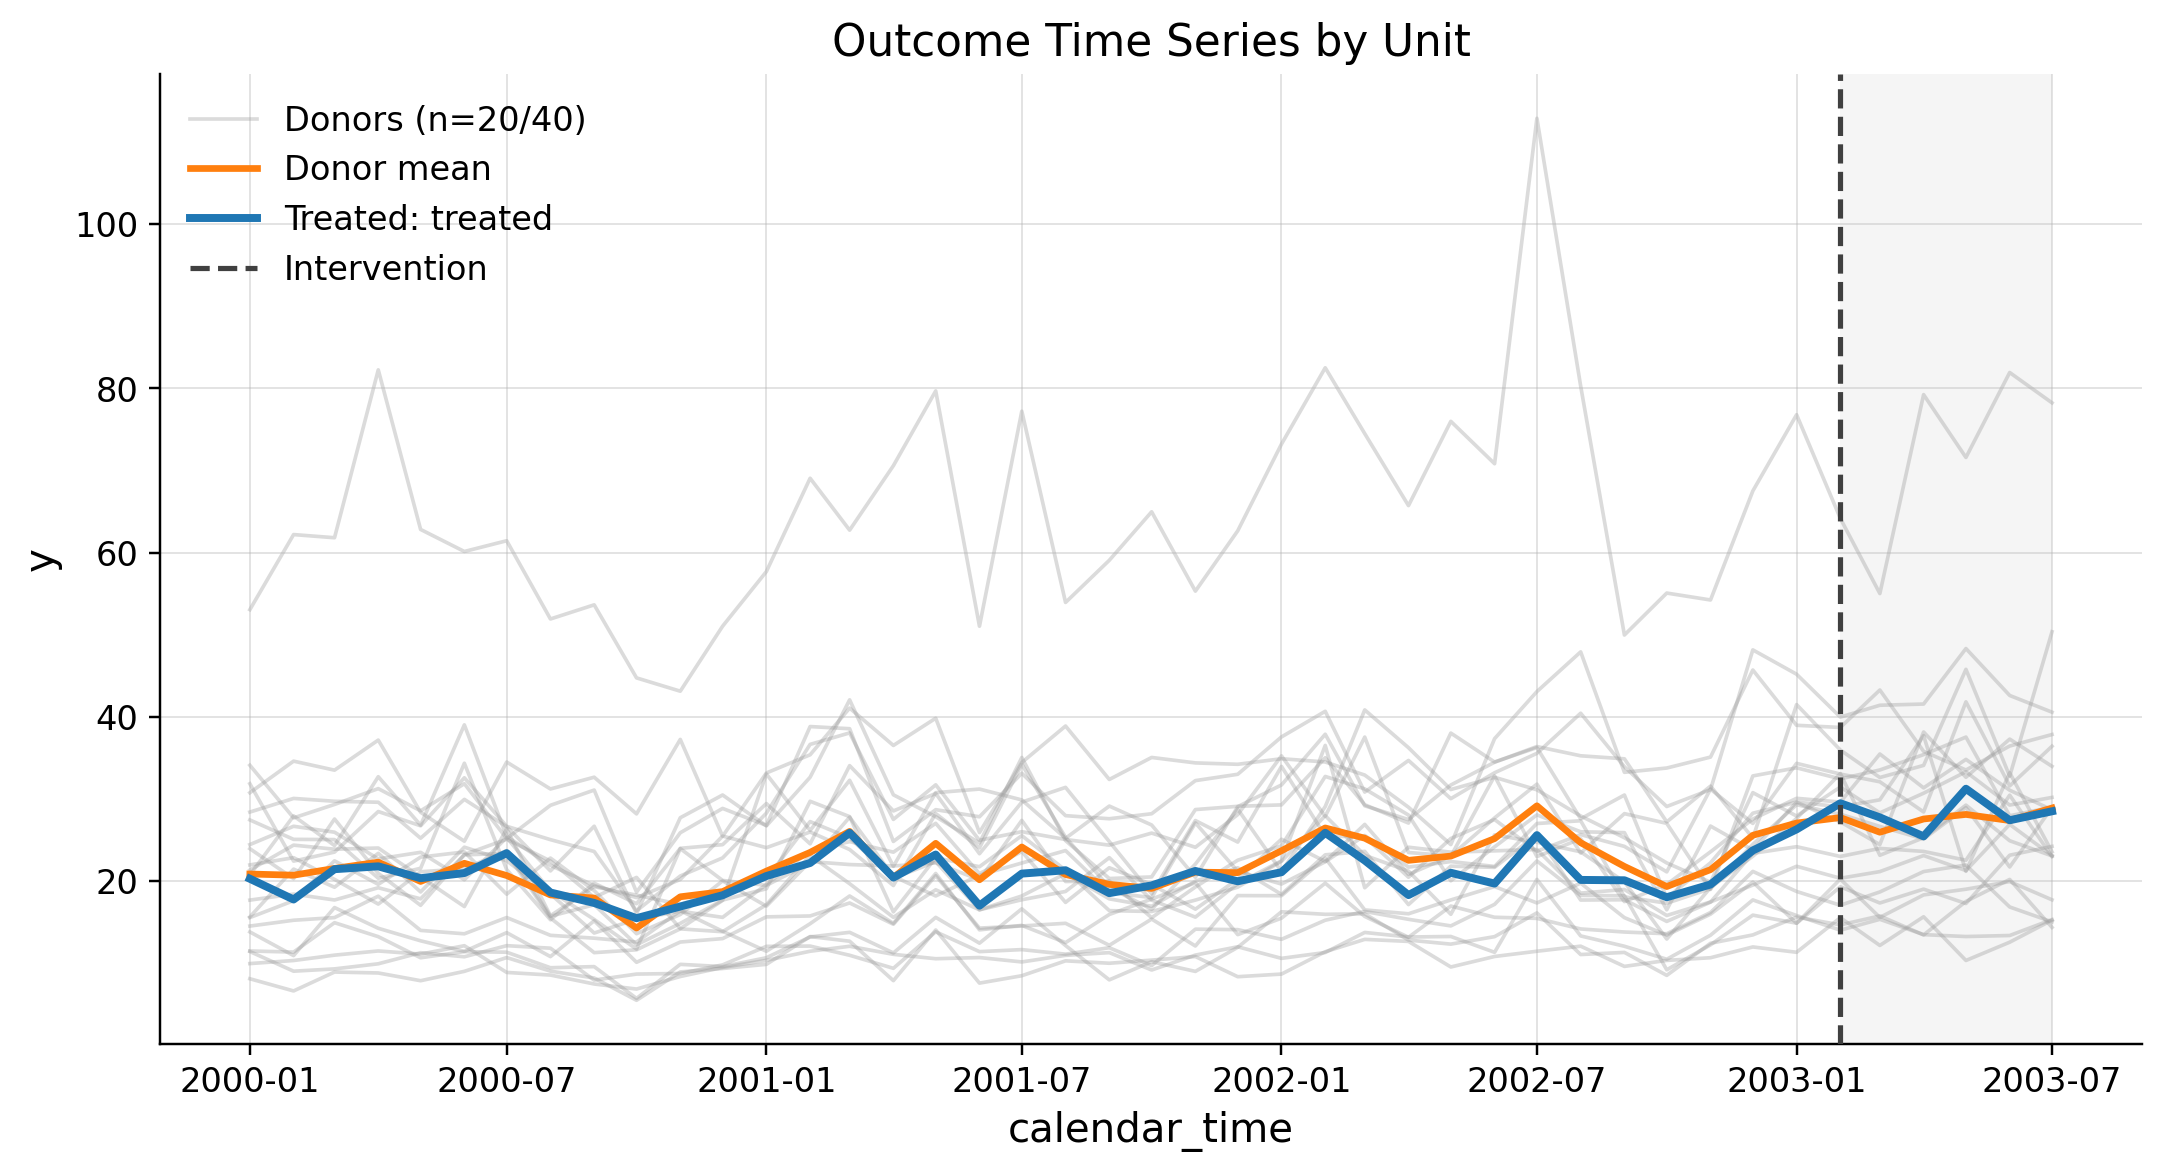

In [6]:
from causalis.scenarios.synthetic_control.refutation import outcome_panel_plot
outcome_panel_plot(paneldata)

# Inference

In [7]:
from causalis.scenarios.synthetic_control import AugmentedSyntheticControl
model = AugmentedSyntheticControl(lambda_aug=50).fit(paneldata)
result = model.estimate()

In [8]:
result.summary()

,value
field,
estimand,average_post_effect
model,AugmentedSyntheticControl
inference,average_att_ttest
value,"3.9456 (ci_abs: 0.3664, 7.5249)"
value_relative,"16.0707 (ci_rel: 1.4922, 30.6491)"
alpha,0.0500
p_value,0.0417
is_significant,True
post_outcome_d_mean,28.3185


So the avarage effect per period is 3.9456 with (ci_abs: 0.3664, 7.5249)

# Refutation

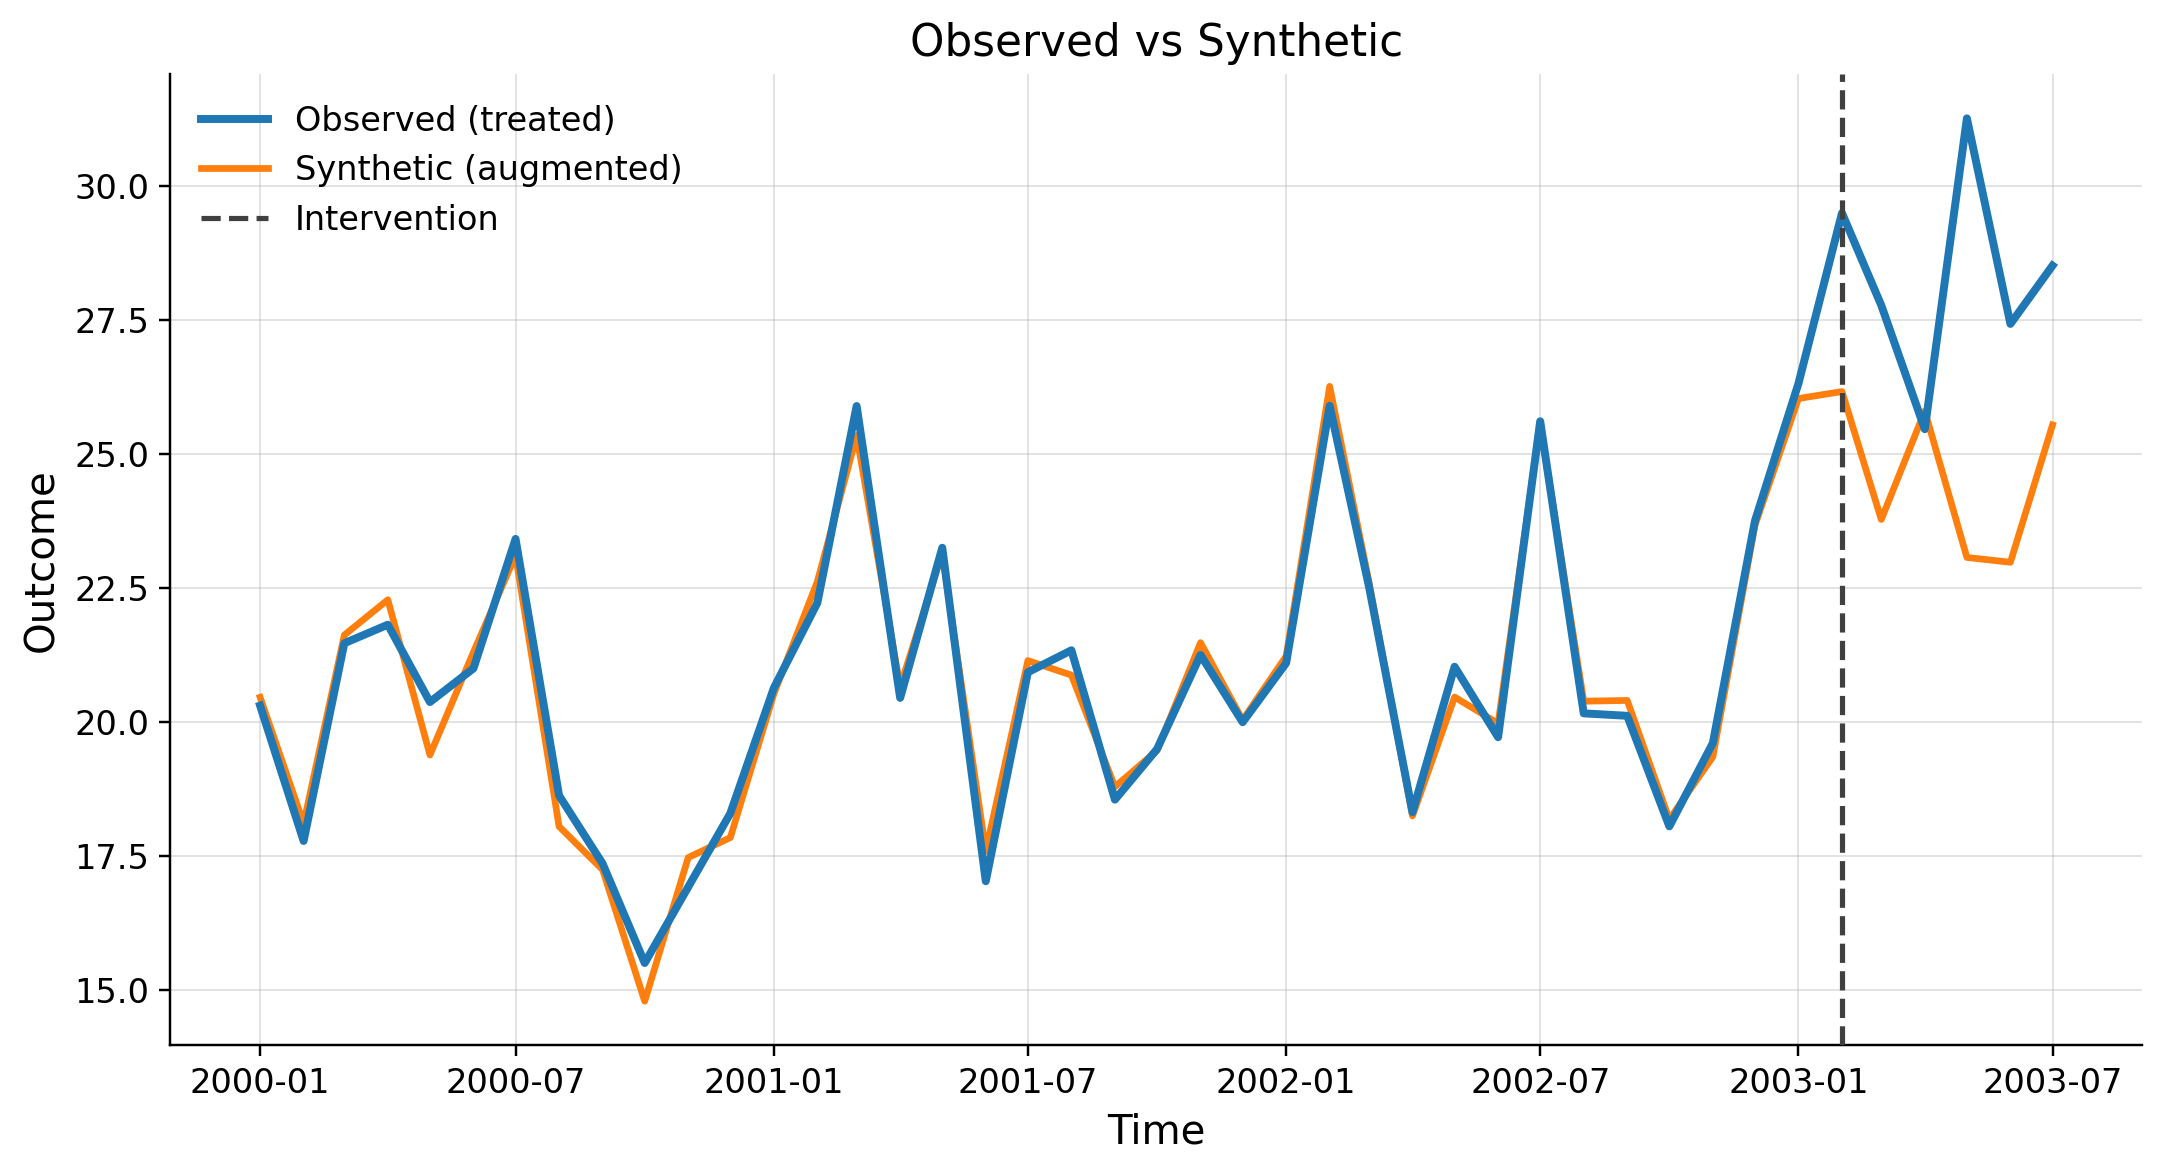

In [9]:
from causalis.scenarios.synthetic_control.refutation import observed_vs_synthetic_plot
observed_vs_synthetic_plot(result)

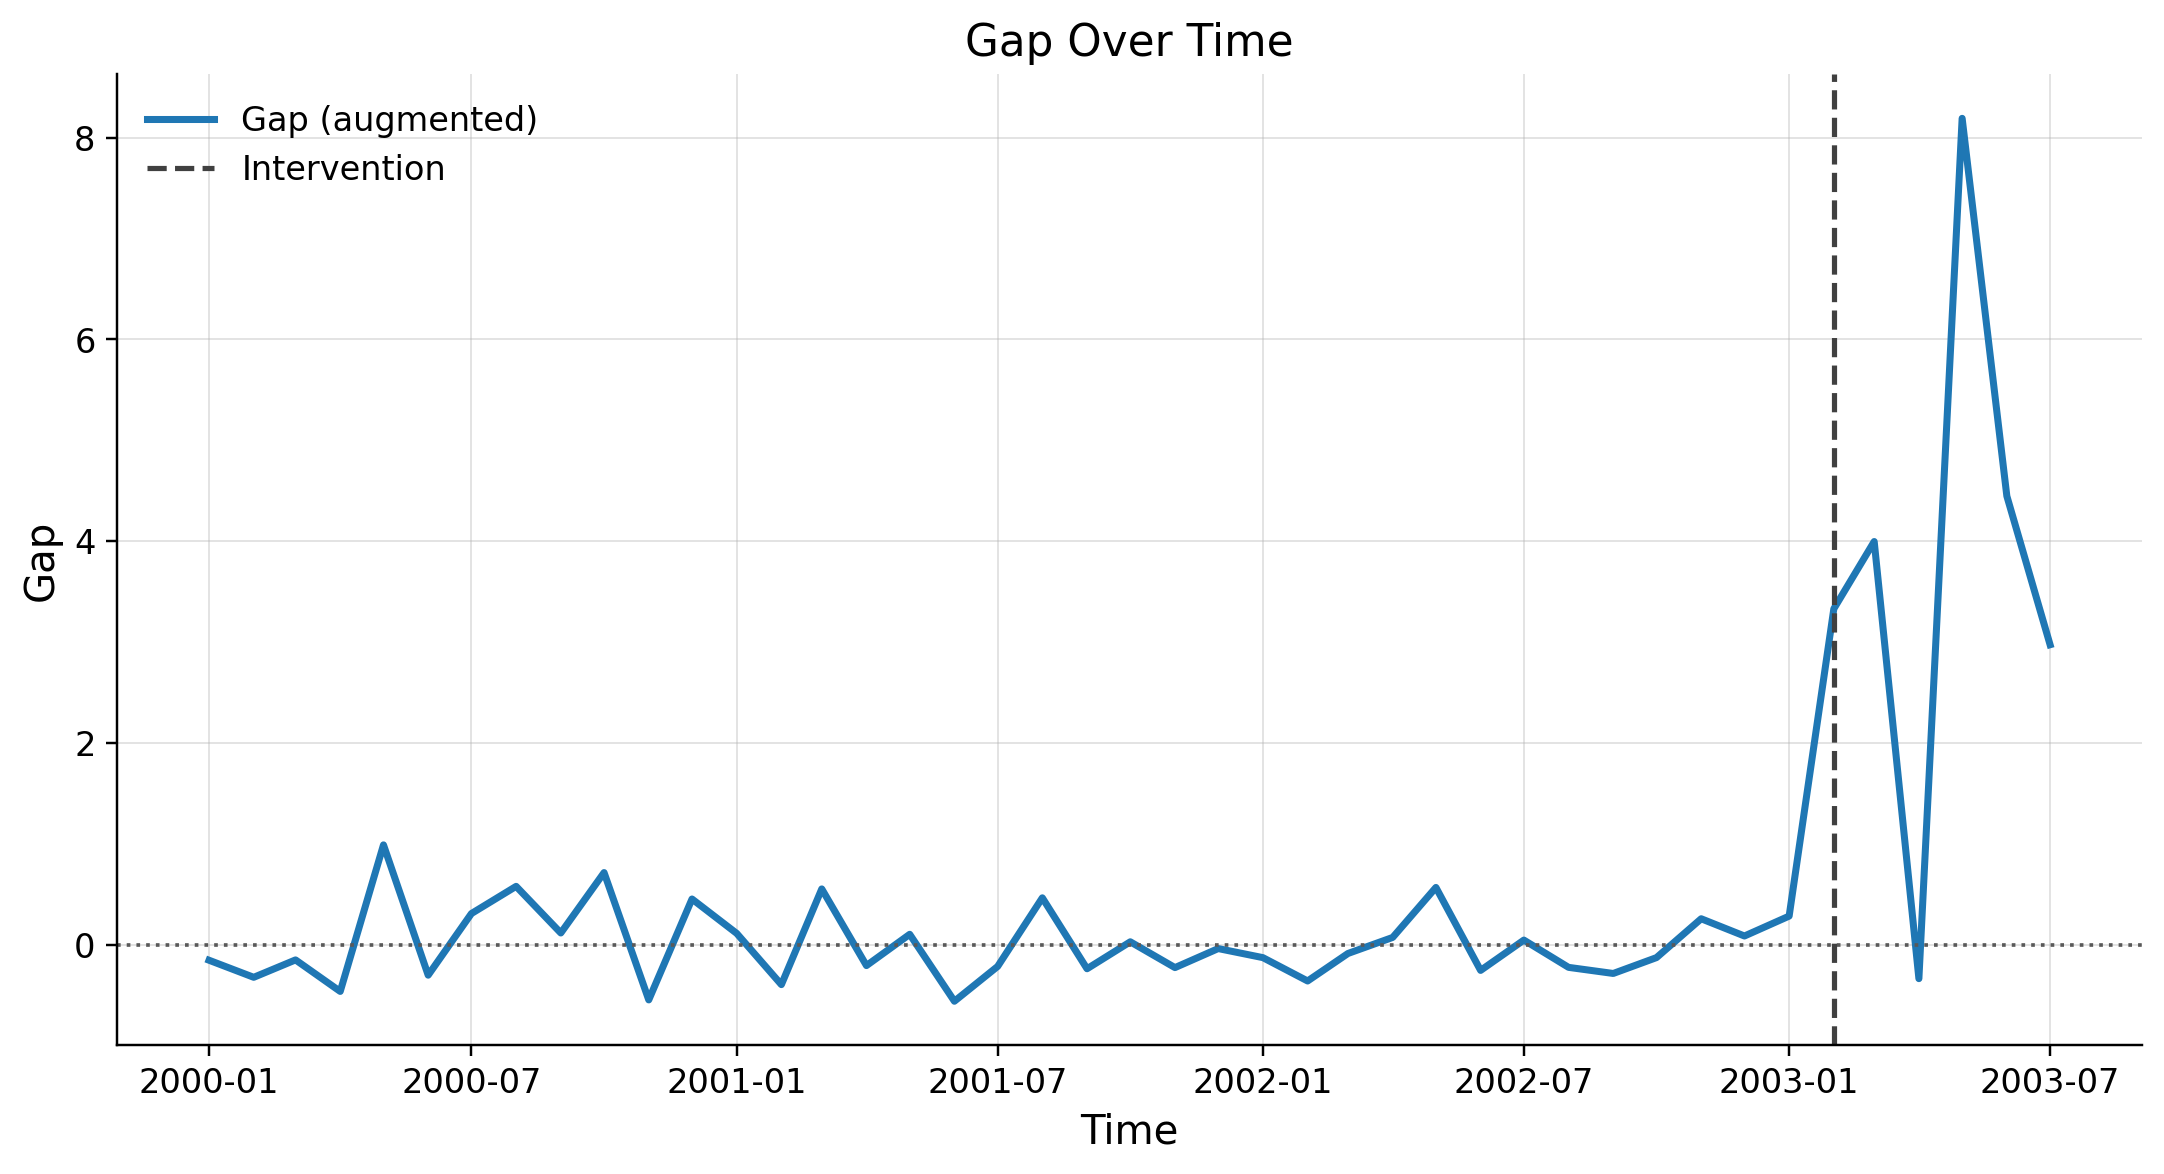

In [10]:
from causalis.scenarios.synthetic_control.refutation import gap_over_time_plot
gap_over_time_plot(result)

As we see synthetic prediction of treated unit is close to real behavior before the intervention and has a gap after it

## Placebo

In [11]:
from causalis.scenarios.synthetic_control.refutation import (placebo_in_time_table,
                                                             placebo_in_space_table)

In [12]:
placebo_in_time_table(result, paneldata)

,placebo_treatment_start,n_pre_before_placebo,n_post_after_placebo,average_att_placebo,ci_lower,ci_upper,p_value,rejects_zero,pre_fit_metric
0,2000-03,2,6,1.882234,-16.331756,20.096223,0.414358,False,3.892700e-09
1,2000-04,3,6,1.269647,-2.922810,5.462105,0.322397,False,4.675707e-08
2,2000-05,4,6,1.558211,-2.782112,5.898534,0.262430,False,7.740750e-09
3,2000-06,5,6,1.314722,-2.945265,5.574709,0.315493,False,8.664180e-09
4,2000-07,6,6,1.415188,-1.584680,4.415056,0.179511,False,8.107963e-09
5,2000-08,7,6,1.303852,-3.103501,5.711204,0.331010,False,6.429904e-04
6,2000-09,8,6,0.780444,-2.048430,3.609318,0.357094,False,1.040816e-03
7,2000-10,9,6,0.096428,-5.840239,6.033095,0.950643,False,9.916453e-04
8,2000-11,10,6,-0.153322,-5.298897,4.992253,0.909715,False,9.340734e-04
9,2000-12,11,6,-0.446809,-6.734040,5.840422,0.788669,False,8.344978e-04


We pretend treatment has happened earlier.
- placebo_treatment_start - where treatment starts
- n_pre_before_placebo - how many periods were fitted before the treatment
- n_post_after_placebo - how many periods were fitted after the treatment
- average_att_placebo - average_post_effect
- rejects_zero - p_value < alpha

So weak robustness when we have many rows have rejects_zero = false and average_att_placebo is small

In [13]:
placebo_in_space_table(result, paneldata)

,unit_id,pre_rmse,post_rmse,post_pre_rmspe_ratio,average_post_gap,max_abs_post_gap,rank_post_pre_rmspe_ratio,is_actual_treated
0,donor_36,0.126184,5.361690,42.491118,-3.645156,8.686013,1,False
1,donor_1,0.090722,3.685575,40.625069,-1.702321,5.149012,2,False
2,donor_9,0.270737,9.590485,35.423589,-4.579774,17.029518,3,False
3,treated,0.159791,5.312488,33.246376,1.536004,9.708560,4,True
4,donor_11,0.465310,14.624468,31.429523,10.645438,20.023546,5,False
5,donor_35,0.325994,9.955574,30.539167,-5.317530,16.717692,6,False
6,donor_10,0.401070,12.221049,30.471133,-7.281390,19.769855,7,False
7,donor_23,0.303599,9.205645,30.321706,3.990897,17.303771,8,False
8,donor_24,0.135587,4.098194,30.225576,3.095115,6.144010,9,False
9,donor_8,0.058817,1.748603,29.729696,0.146309,3.260276,10,False


How to read columns:

- unit_id: unit used as treated in that placebo run.
- pre_rmse: pre-treatment fit error (lower is better).
- post_rmse: post-treatment fit error.
- post_pre_rmspe_ratio: post_rmse / pre_rmse (main Abadie-style statistic).
- average_post_gap: mean post-treatment gap (observed - synthetic).
- max_abs_post_gap: largest absolute post gap.
- rank_post_pre_rmspe_ratio: rank of ratio, descending (1 = largest ratio).
- is_actual_treated: True for your real treated unit.

Interpretation:
You want the real treated unit (is_actual_treated=True) to have one of the largest post_pre_rmspe_ratio values (ideally rank near 1).
If many placebo units have similar/larger ratios, treatment effect is less convincing.
Also check pre_rmse: if pre-fit is poor for some placebos, their high ratios are less informative.

## Sensitivity

In [14]:
from causalis.scenarios.synthetic_control.refutation import leave_one_donor_out_sensitivity
leave_one_donor_out_sensitivity(result, paneldata)

,dropped_donor,average_att_reestimated,delta_vs_full_model,pre_rmse_reestimated,max_weight_after_refit,effective_n_donors_after_refit
0,donor_1,4.207858,0.262223,0.171405,0.303030,0.946472
1,donor_10,4.587795,0.642161,0.160802,0.349188,0.909245
2,donor_11,4.189136,0.243502,0.160120,0.353247,0.909496
3,donor_12,4.916255,0.970621,0.189167,0.336427,0.978294
4,donor_13,4.468127,0.522492,0.162525,0.341735,0.927949
5,donor_14,4.725072,0.779438,0.160180,0.358832,0.910183
6,donor_15,4.513050,0.567416,0.169711,0.391910,0.908753
7,donor_16,4.382022,0.436387,0.159357,0.352835,0.903756
8,donor_17,3.622184,-0.323451,0.158809,0.356443,0.899310
9,donor_18,4.436393,0.490759,0.198704,0.368078,1.149355


- dropped_donor: donor unit removed in that refit.
- average_att_reestimated: ATT after removing that donor.
- delta_vs_full_model: reestimated_ATT - original_full_model_ATT.
Near 0 → estimate is stable to that donor.
Large |deltal → that donor is influential.
- pre_rmse_reestimated: pre-treatment fit error after refit. Higher than baseline → worse pre-fit when donor is removed.
- max_weight_afterrefit: largest donor weight in refit.Very high (close to 1) → dependence on one donor.
-  effective_n_donors_after_refit: effective donor count (1 / sum (w^2)). Lower → concentration on fewer donors.

## Model

In [15]:
from causalis.scenarios.synthetic_control.refutation import run_scm_diagnostics
run_scm_diagnostics(result, paneldata)

,test,flag,value,threshold,message
0,pre_rmse_augmented,GREEN,0.366248,<= 0.5254,Pre-treatment RMSE is within tolerance.
1,max_abs_pre_gap_augmented,GREEN,0.988290,<= 1.314,Largest pre-treatment gap is within tolerance.
2,mean_gap_last_k_pre_augmented,GREEN,0.207285,<= 0.6568,Average gap in the last 3 pre periods is cente...
3,max_abs_weight_augmented,GREEN,0.201943,<= 2,No extreme augmented donor weight detected (mo...
4,l1_norm_weights_augmented,GREEN,2.245170,<= 5,Total absolute augmented weight mass is contro...
5,negative_weight_share,GREEN,0.277300,<= 0.3,Negative-weight share is moderate.
6,slsqp_fallback_count,GREEN,0.000000,== 0,No optimizer fallback events recorded.
7,suppressed_fit_warning_count,GREEN,0.000000,== 0,No suppressed fit warnings were captured.


We can call our estimate robust